# Spatial dynamics of vaccination in a simple epidemiological model

_Author_: Joe Mihaljevic

The goal of this dev log is to demonstrate various methodologies to simulate vaccination in a spatial context, using `epymorph`. 
The routines will be purposefully simplified, as demonstration, and will build in complexity so that new users can understand how they might build their own vaccination modeling framework. 

## Simple SIRS-V model

Let's begin with a simple SIRS-V model of the form:
$\begin{align}
\frac{dS}{dt} &= -\frac{\beta SI}{N} - \nu + \delta R \\
\frac{dI}{dt} &= \frac{\beta SI}{N} - \gamma I \\
\frac{dR}{dt} &= \gamma I - \delta R \\
\frac{dV}{dt} &= \nu
\end{align}$

Here, we assume a standard SIR model with waning immunity (i.e., an SIRS).
For the vaccine class, $V$, we assume a constant linear rate of vaccine uptake, noted as parameter $\nu$. 
Although a constant linear rate is simplistic, we will see that, using `epymorph`, we can layer on complexity, such as by assuming a time- and/or location-varying rate of update (i.e., $\nu_{t,k}$, where $t$ is time, and $k$ is location).

### Setup for single-node simulation

First, we will run the model in a single location (i.e., node) using static parameter values. Let's assume we are running the model with a single node representing all of Cook County, IL. 

(1) Construct the intra-population model (IPM) as a compartmental model `class`

In [82]:
# REQUIRED IMPORTS
# import numpy as np
from sympy import Max

from epymorph import *
from epymorph.compartment_model import *
from epymorph.data_shape import Shapes
from epymorph.simulation import AttributeDef

In [83]:
class SIRV(CompartmentModel):
    """Defines a compartmental IPM."""

    compartments = [
        compartment("S"),
        compartment("I"),
        compartment("R"),
        compartment("V"),
    ]

    requirements = [
        AttributeDef("beta", type=float, shape=Shapes.TxN, comment="transmission rate"),
        AttributeDef("gamma", type=float, shape=Shapes.TxN, comment="recovery rate"),
        AttributeDef(
            "delta", type=float, shape=Shapes.TxN, comment="waning immunity rate"
        ),
        AttributeDef(
            "nu", type=float, shape=Shapes.TxN, comment="average vaccine allocation"
        ),
    ]

    def edges(self, symbols):
        [
            S,
            I,
            R,
            V,
        ] = symbols.all_compartments
        [
            beta,
            gamma,
            delta,
            nu,
        ] = symbols.all_requirements

        N = Max(1, S + I + R + V)

        return [
            edge(S, I, rate=beta * S * I / N),
            edge(I, R, rate=gamma * I),
            edge(R, S, rate=delta * R),
            edge(S, V, rate=nu),
        ]


We can use the `render` function to display a graphical representation of the model, which helps us double-check that we set it up correctly.

In [84]:
# render(SIRV())

(2) Specify the geographical scope in which you want to simulate your IPM. In this case, we're assuming a single location scope. We use the ADRIO system, and again, we'll assume the location is Cook County, IL, which has FIPS code `17031`. We'll specify a year related to the US Census data, here 2020. 

In [85]:
from epymorph.geography.us_census import CountyScope

In [86]:
cook_county = CountyScope.in_counties(["Cook, IL"], year=2020)
# Use the `labels` method to verify you go the right county
cook_county.labels

array(['Cook, IL'], dtype='<U8')

(3) Build the RUME (runnable modeling experiment), which requires various arguments, which we will display below:

In [87]:
from epymorph.adrio import acs5, us_tiger
from epymorph.data.mm.no import No as NoMovement

In [88]:
cook_rume = SingleStrataRume.build(
    # Load the SIRV IPM
    ipm=SIRV(),
    # This is where you specify a movement model. We don't have movement (single node)
    mm=NoMovement(),
    # Place your geographical scope, which we defined above
    scope=cook_county,
    # Create a SingleLocation initializer. 10 initially infected individuals in the node
    init=init.SingleLocation(location=0, seed_size=10),
    # Set the time-frame to simulate (100 days)
    time_frame=TimeFrame.of("2020-01-01", 100),
    # Provide model parameter values (IPM and MM)
    params={
        "beta": 0.9,
        "gamma": 0.5,
        "delta": 1 / 90.0,
        "nu": 5000.0,
        # Geographic data can be loaded using ADRIOs
        "population": acs5.Population(),
        "meta::geo::label": us_tiger.Name(),
    },
)

In [89]:
# Check to see if you specified required params and variables
cook_rume.requirements

OrderedDict([(AbsoluteName(strata='gpm:all', module='ipm', id='beta'),
              AttributeDef(name='beta', type=<class 'float'>, shape=TimeAndNode(), default_value=None, comment='transmission rate')),
             (AbsoluteName(strata='gpm:all', module='ipm', id='gamma'),
              AttributeDef(name='gamma', type=<class 'float'>, shape=TimeAndNode(), default_value=None, comment='recovery rate')),
             (AbsoluteName(strata='gpm:all', module='ipm', id='delta'),
              AttributeDef(name='delta', type=<class 'float'>, shape=TimeAndNode(), default_value=None, comment='waning immunity rate')),
             (AbsoluteName(strata='gpm:all', module='ipm', id='nu'),
              AttributeDef(name='nu', type=<class 'float'>, shape=TimeAndNode(), default_value=None, comment='average vaccine allocation')),
             (AbsoluteName(strata='gpm:all', module='init', id='population'),
              AttributeDef(name='population', type=<class 'int'>, shape=Node(), default_value=

(4) Generate a simulator, run the simulation, and store the output object

In [90]:
# Construct a simulator for the RUME
cook_sim = BasicSimulator(cook_rume)

# Run inside a sim_messaging context to display a nice progress bar
with sim_messaging():
    # Run and save the simulation Output object for later
    out_cook = cook_sim.run(
        # Use a seeded RNG (for the sake of keeping this notebook's results consistent)
        # This parameter is optional; by default a new RNG is constructed for each run
        # using numpy's default_rng
        rng_factory=default_rng(1)
    )

Running simulation (BasicSimulator):
• 2020-01-01 to 2020-04-10 (100 days)
• 1 geo nodes
  |####################| 100% 
Runtime: 0.011s


The output object is an `np.array` that holds the counts in the IPM compartments and the counts of new events, per node, per time.

In [91]:
# Raw output dimensions
out_cook.dim

SimDimensions(tau_step_lengths=(1.0,), tau_steps=1, start_date=datetime.date(2020, 1, 1), days=100, ticks=100, nodes=1, compartments=4, events=4, TNCE=(100, 1, 4, 4))

(5) Use internal plotting functions to check the output

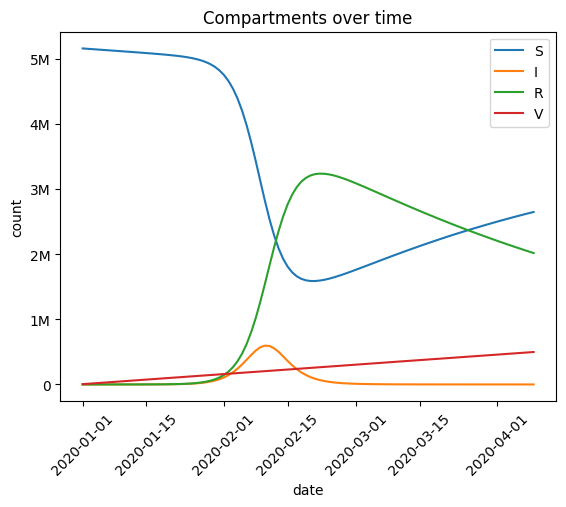

In [92]:
out_cook.plot.line(
    geo=cook_rume.scope.select.all(),
    time=cook_rume.time_frame.select.all(),
    quantity=cook_rume.ipm.select.compartments(),
    title="Compartments over time",
    label_format="{q}",
)


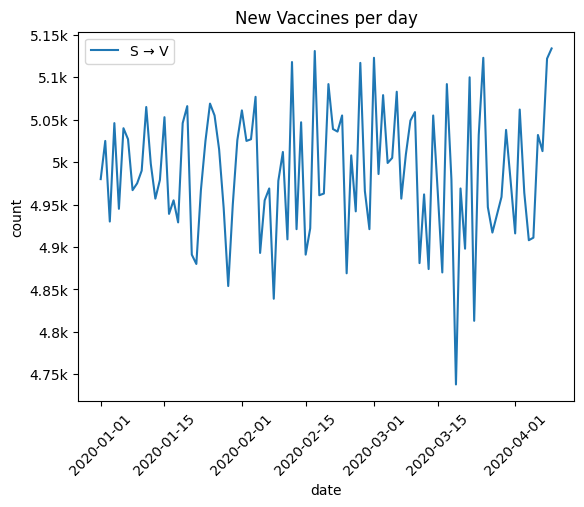

In [93]:
out_cook.plot.line(
    geo=cook_rume.scope.select.all(),
    time=cook_rume.time_frame.select.all(),
    quantity=cook_rume.ipm.select.events("S->V"),
    title="New Vaccines per day",
    label_format="{q}",
)

In [94]:
out_cook.table.chart(
    geo=cook_rume.scope.select.all(),
    time=cook_rume.time_frame.select.all(),
    quantity=cook_rume.ipm.select.all(),
)

,geo,quantity,chart
0,"Cook, IL",S,██████▇▅▄▃▃▃▄▄▄▄▄▄▄▅
1,"Cook, IL",I,▁▁▁▁▁▂▄█▆▃▂▁▁▁▁▁▁▁▁▁
2,"Cook, IL",R,▁▁▁▁▁▁▂▄▇███▇▇▇▆▆▆▆▅
3,"Cook, IL",V,▁▂▂▂▃▃▃▄▄▄▅▅▆▆▆▇▇▇██
4,"Cook, IL",S → I,▁▁▁▁▁▂▄██▄▂▁▁▁▁▁▁▁▁▁
5,"Cook, IL",I → R,▁▁▁▁▁▁▂▆█▅▂▁▁▁▁▁▁▁▁▁
6,"Cook, IL",R → S,▁▁▁▁▁▁▁▂▅▇███▇▇▇▆▆▆▆
7,"Cook, IL",S → V,████████████████████


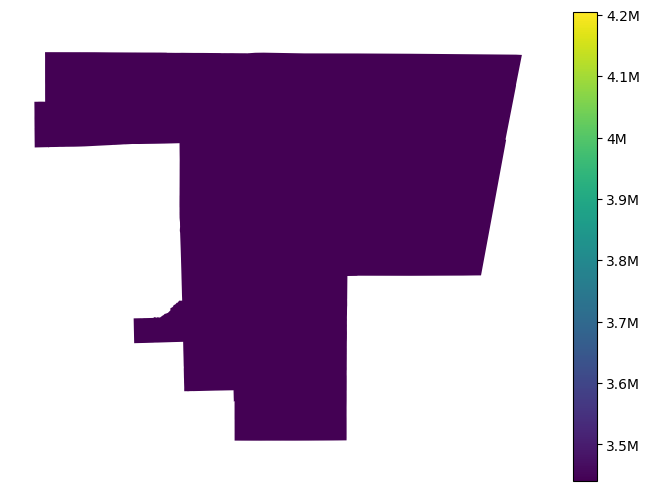

In [95]:
out_cook.map.choropleth(
    geo=cook_rume.scope.select.all(),
    time=cook_rume.time_frame.select.all().agg(compartments="max"),
    quantity=cook_rume.ipm.select.events("S->I"),
)